In [115]:
"""this is the first assignment of Natural language proccessing
   this was made by group 11 comprised of:
   Miruna Lungu (S5882206)
   Andrejs Tupikins (S5607442)
   Prayer Aguebor (S5901782)
"""

'this is the first assignment of Natural language proccessing\n   this was made by group 11 comprised of:\n   Miruna Lungu (S5882206)\n   Andrejs Tupikins (S5607442)\n   Prayer Aguebor (S5901782)\n'

In [116]:
import re
import html
import string
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.svm import LinearSVC
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
target_names = ["World", "Sports", "Business", "Sci/Tech"]

In [117]:
news_dataset = load_dataset("ag_news")

In [118]:
train_testval = news_dataset["train"].train_test_split(test_size=0.2, seed=42)
test_valid = train_testval["test"].train_test_split(test_size=0.5, seed=42)

In [119]:
"""data split into 80% train 10% validation 10% test """
train_data = train_testval["train"]
val_data = test_valid["train"]
test_data = test_valid["test"]

In [120]:
#training data
train_text = train_data["text"]
train_label = train_data["label"]

#validation data
val_text = val_data["text"]
val_label = val_data["label"]

#used at the end for testing
test_text = test_data["text"]
test_label = test_data["label"]


In [121]:
def preProcessing(text):
    text = html.unescape(text)
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"\d+", "", text) # Remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\W+", " ", text)# Remove non-word characters
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    lowercase=False,
    preprocessor=preProcessing,
)

train_matrix = vectorizer.fit_transform(train_text)
validation_vect = vectorizer.transform(val_text)

In [122]:
svm_model = LinearSVC(class_weight= 'balanced', C=0.1, random_state=42)
svm_model.fit(train_matrix, train_label)
train_preds = svm_model.predict(train_matrix)
validation_preds = svm_model.predict(validation_vect)

print(
    "TRAIN SVM model\n",
    classification_report(
        train_label, train_preds, target_names=target_names, digits=4
    ),
)

print(
    "VALIDATION SVM model\n",
    classification_report(
        val_label, validation_preds, target_names=target_names, digits=4
    ),
)


TRAIN SVM model
               precision    recall  f1-score   support

       World     0.9571    0.9193    0.9378     23949
      Sports     0.9645    0.9933    0.9787     23949
    Business     0.9194    0.9119    0.9156     24061
    Sci/Tech     0.9167    0.9330    0.9248     24041

    accuracy                         0.9393     96000
   macro avg     0.9394    0.9394    0.9392     96000
weighted avg     0.9394    0.9393    0.9392     96000

VALIDATION SVM model
               precision    recall  f1-score   support

       World     0.9413    0.9073    0.9240      3021
      Sports     0.9540    0.9861    0.9698      3027
    Business     0.9056    0.8828    0.8940      2987
    Sci/Tech     0.8878    0.9123    0.8999      2965

    accuracy                         0.9223     12000
   macro avg     0.9221    0.9221    0.9219     12000
weighted avg     0.9224    0.9223    0.9221     12000



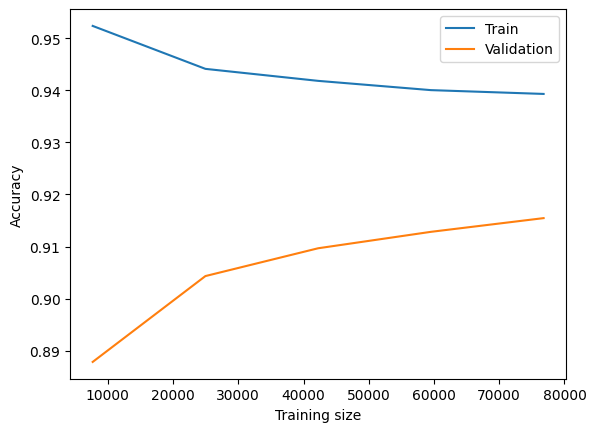

In [123]:
result = learning_curve(
    svm_model, train_matrix, train_label, cv=5, scoring="accuracy", n_jobs=-1
)
train_sizes, train_scores, val_scores = result[:3]

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation")
plt.legend()
plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.show()


In [124]:
"""test set on linear svm"""
test_vect = vectorizer.transform(test_text)
test_pred = svm_model.predict(test_vect)


print(
    "test set SVM model\n",
    classification_report(
        test_label, test_pred, target_names=target_names, digits=4
    ),
)

test set SVM model
               precision    recall  f1-score   support

       World     0.9330    0.8957    0.9140      3030
      Sports     0.9545    0.9858    0.9699      3024
    Business     0.8893    0.8814    0.8853      2952
    Sci/Tech     0.8826    0.8968    0.8897      2994

    accuracy                         0.9152     12000
   macro avg     0.9149    0.9149    0.9147     12000
weighted avg     0.9151    0.9152    0.9150     12000



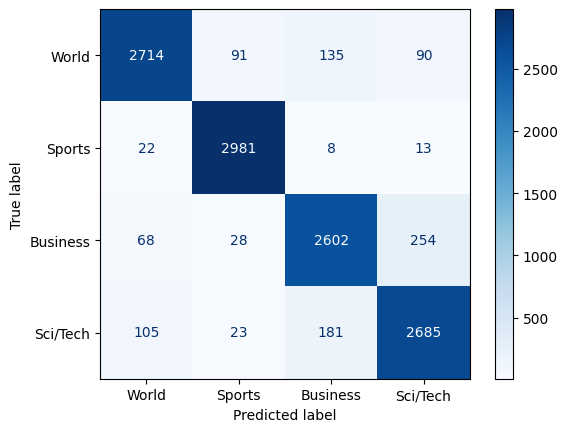

In [125]:
ConfusionMatrixDisplay.from_predictions(
    test_label, test_pred, display_labels=target_names, cmap="Blues"
)


In [132]:
mis_idx = [i for i in range(len(test_label)) if test_label[i] != test_pred[i]]
cleaned_test_text = [preProcessing(test) for test in test_text]
misclassified_examples = []

for i in mis_idx[:20]:  # take first 20
    misclassified_examples.append(
        {
            "text": cleaned_test_text[i],
            "true": target_names[test_label[i]],
            "pred": target_names[test_pred[i]]
        }
    )
df_errors = pd.DataFrame(misclassified_examples)
df_errors.head(20)

,text,true,pred
0,Only Injury Can Stop Peerless Federer at Maste...,World,Sports
1,All terror attacks use false passports claims ...,Sci/Tech,World
2,UK student fraud hits record level A record nu...,World,Sci/Tech
3,Daiei to Apply for Aid From Gov t Fund Trouble...,World,Business
4,Golf Mickelson hits magic Phil Mickelson scorc...,World,Sports
5,Retailers Stock Up on Latest Gadgets AP AP Som...,Sci/Tech,Business
6,DC s No On Dangerous Cities List WASHINGTON Wa...,Business,Sports
7,Inspector General Says EPA Rule Aids Polluters...,Sci/Tech,Business
8,Nintendo cuts Game Boy Advance price Japanese ...,Business,Sci/Tech
9,Paris showcase for Apples vision Apple has bee...,World,Sci/Tech


In [127]:
Logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
Logistic_model.fit(train_matrix, train_label)
train_preds = Logistic_model.predict(train_matrix)
validation_preds = Logistic_model.predict(validation_vect)
print(
    "TRAIN Logistic model\n",
    classification_report(
        train_label, train_preds, target_names=target_names, digits=4
    ),
)

print(
    "VALIDATION Logisitc model\n",
    classification_report(
        val_label, validation_preds, target_names=target_names, digits=4
    ),
)


TRAIN Logistic model
               precision    recall  f1-score   support

       World     0.9593    0.9280    0.9434     23949
      Sports     0.9694    0.9924    0.9807     23949
    Business     0.9264    0.9207    0.9236     24061
    Sci/Tech     0.9249    0.9388    0.9318     24041

    accuracy                         0.9449     96000
   macro avg     0.9450    0.9450    0.9449     96000
weighted avg     0.9450    0.9449    0.9448     96000

VALIDATION Logisitc model
               precision    recall  f1-score   support

       World     0.9353    0.9096    0.9223      3021
      Sports     0.9559    0.9812    0.9684      3027
    Business     0.9048    0.8781    0.8913      2987
    Sci/Tech     0.8835    0.9106    0.8969      2965

    accuracy                         0.9201     12000
   macro avg     0.9199    0.9199    0.9197     12000
weighted avg     0.9201    0.9201    0.9199     12000



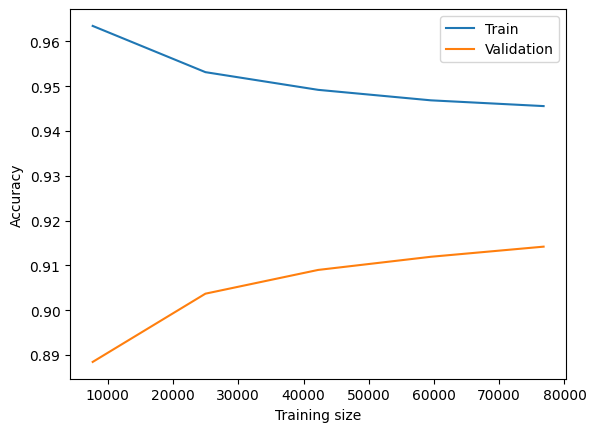

In [128]:
result = learning_curve(
    Logistic_model, train_matrix, train_label, cv=5, scoring="accuracy", n_jobs=-1
)
train_sizes, train_scores, val_scores = result[:3]

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation")
plt.legend()
plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.show()


In [129]:
"""model check on the text data"""
test_vect = vectorizer.transform(test_text)
test_preds = Logistic_model.predict(test_vect)

print(
    "Test set\n",
    classification_report(test_label, test_preds, target_names=target_names, digits=4),
)



Test set
               precision    recall  f1-score   support

       World     0.9332    0.8987    0.9156      3030
      Sports     0.9575    0.9828    0.9700      3024
    Business     0.8901    0.8831    0.8866      2952
    Sci/Tech     0.8816    0.8978    0.8896      2994

    accuracy                         0.9158     12000
   macro avg     0.9156    0.9156    0.9154     12000
weighted avg     0.9158    0.9158    0.9157     12000



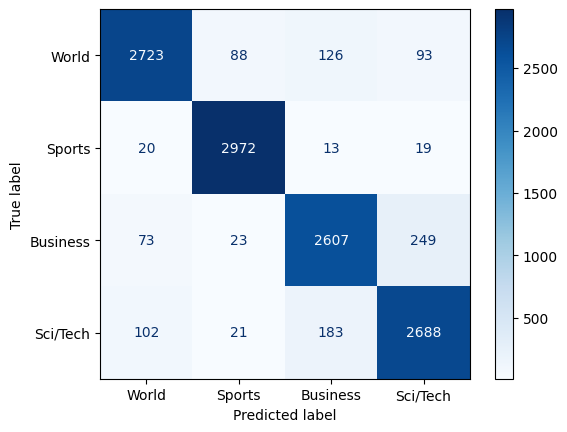

In [130]:
ConfusionMatrixDisplay.from_predictions(
    test_label, test_preds, display_labels=target_names, cmap="Blues"
)


In [131]:
mis_idx = [i for i in range(len(test_label)) if test_label[i] != test_preds[i]]
cleaned_test_text = [preProcessing(test) for test in test_text]
misclassified_examples = []

for i in mis_idx[:20]:  # take first 20
    misclassified_examples.append(
        {
            "text": cleaned_test_text[i],
            "true": target_names[test_label[i]],
            "pred": target_names[test_preds[i]],
        }
    )
df_errors = pd.DataFrame(misclassified_examples)
df_errors.head(20)

,text,true,pred
0,Only Injury Can Stop Peerless Federer at Maste...,World,Sports
1,UK student fraud hits record level A record nu...,World,Sci/Tech
2,Daiei to Apply for Aid From Gov t Fund Trouble...,World,Business
3,Golf Mickelson hits magic Phil Mickelson scorc...,World,Sports
4,DC s No On Dangerous Cities List WASHINGTON Wa...,Business,Sports
5,Inspector General Says EPA Rule Aids Polluters...,Sci/Tech,Business
6,Nintendo cuts Game Boy Advance price Japanese ...,Business,Sci/Tech
7,Paris showcase for Apples vision Apple has bee...,World,Sci/Tech
8,Oracle Vows Oversupport for PeopleSoft Custome...,Sci/Tech,Business
9,Space Capsule Crashes in Utah DUGWAY PROVING G...,World,Sci/Tech
